Read online retail data (shared in data set section) using csv module and perform following operations.  CSV reader documentation (https://docs.python.org/3/library/csv.html)\
or use following code:
```py
import csv
with open('some.csv', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)
```

Solve:
1. Find mean, std dev, min , max of unitprice field.
2. Draw histogram of unitprice field using matplotlib
3. Find mean of unitprice group by country and plot them
4. Find min and max of unit price group by customerID
5. Find cumulative sales monthly and yearly and plot them using both Matplotlib and Sea Borne.
6. Generate a Box plot for each attribute
7. Analyze each attribute using the factor plot analysis using Seaborne library

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open("../../datasets/OnlineRetail.csv", encoding="latin-1", newline="") as f:
    reader = csv.reader(f)
    lines = list(reader)

In [3]:
header = lines[0]
rows = np.array(lines[1:])
unitprice_col = rows[:, header.index("UnitPrice")].astype(np.float32)

In [4]:
print(f"Mean: {unitprice_col.mean()}")
print(f"Std deviation: {unitprice_col.std()}")
print(f"Max: {unitprice_col.max()}")
print(f"Min: {unitprice_col.min()}")

Mean: 4.611113548278809
Std deviation: 96.759765625
Max: 38970.0
Min: -11062.0595703125


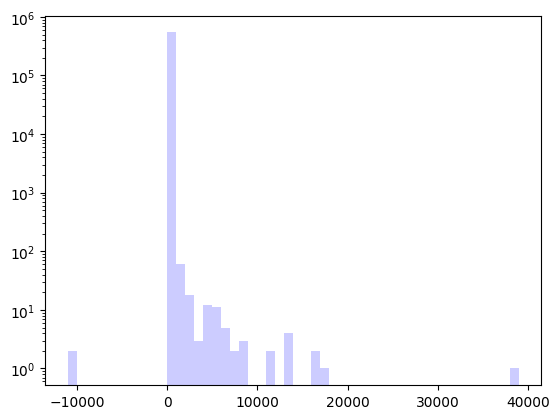

In [5]:
_ = plt.hist(unitprice_col, 50, facecolor="b", alpha=0.2)
plt.yscale("log")

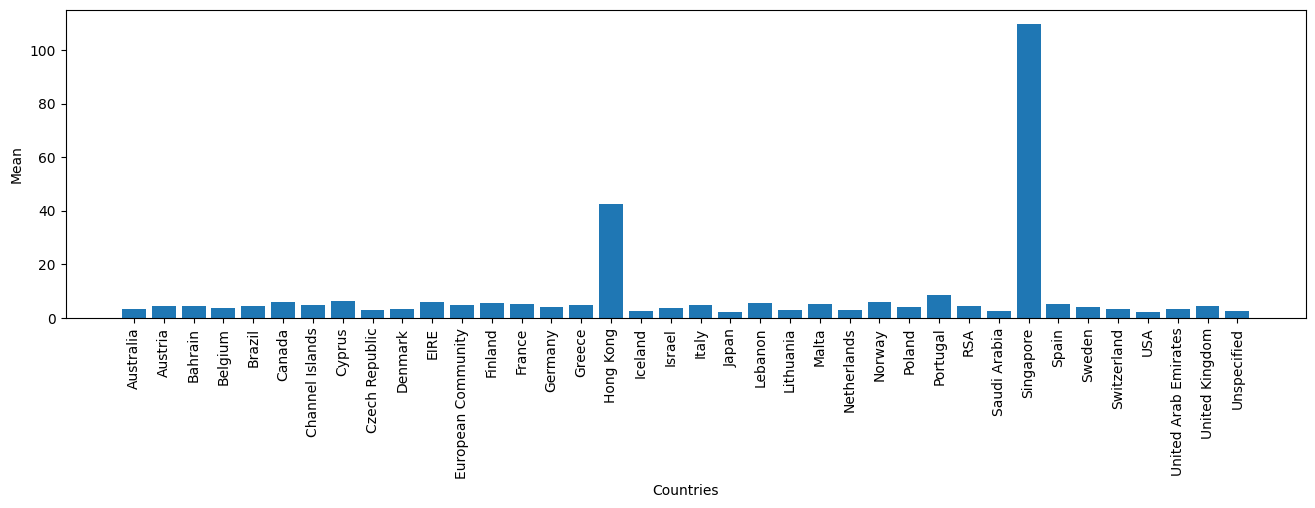

In [6]:
countries = rows[:, header.index("Country")]
unique_countries = np.unique(countries)
country_mean = {
    country.item(): rows[countries == country, header.index("UnitPrice")]
    .astype(np.float32)
    .mean()
    for country in unique_countries
}
x = country_mean.keys()
y = country_mean.values()
plt.figure(figsize=(16, 4))
plt.bar(x, y)
plt.xticks(rotation=90)
plt.xlabel("Countries")
plt.ylabel("Mean")
plt.show()

In [7]:
cust_ids = rows[:, header.index("CustomerID")]
unique_cust_id = np.unique(cust_ids)
cust_min_max = {}
for cust_id in unique_cust_id:
    prices = rows[cust_ids == cust_id, header.index("UnitPrice")].astype(np.float32)
    cust_min_max[cust_id.item()] = [prices.min(), prices.max()]

print(cust_min_max)

{'': [np.float32(-11062.06), np.float32(17836.46)], '12346': [np.float32(1.04), np.float32(1.04)], '12347': [np.float32(0.25), np.float32(12.75)], '12348': [np.float32(0.29), np.float32(40.0)], '12349': [np.float32(0.42), np.float32(300.0)], '12350': [np.float32(0.85), np.float32(40.0)], '12352': [np.float32(0.65), np.float32(376.5)], '12353': [np.float32(1.45), np.float32(9.95)], '12354': [np.float32(0.42), np.float32(16.95)], '12355': [np.float32(1.25), np.float32(12.75)], '12356': [np.float32(0.42), np.float32(18.0)], '12357': [np.float32(0.39), np.float32(25.0)], '12358': [np.float32(0.39), np.float32(40.0)], '12359': [np.float32(0.29), np.float32(145.0)], '12360': [np.float32(0.42), np.float32(40.0)], '12361': [np.float32(1.65), np.float32(15.0)], '12362': [np.float32(0.12), np.float32(29.95)], '12363': [np.float32(0.55), np.float32(7.95)], '12364': [np.float32(0.36), np.float32(15.0)], '12365': [np.float32(0.42), np.float32(320.69)], '12367': [np.float32(0.21), np.float32(18.0)],

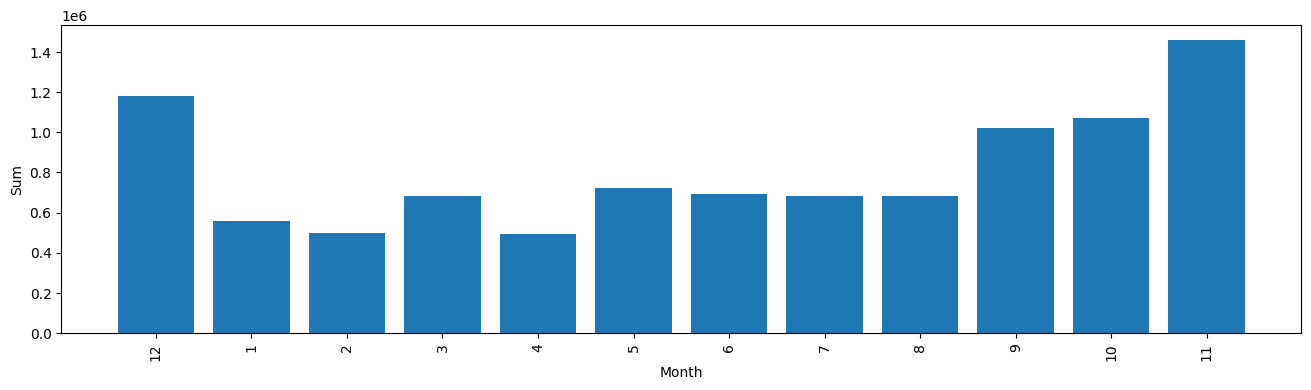

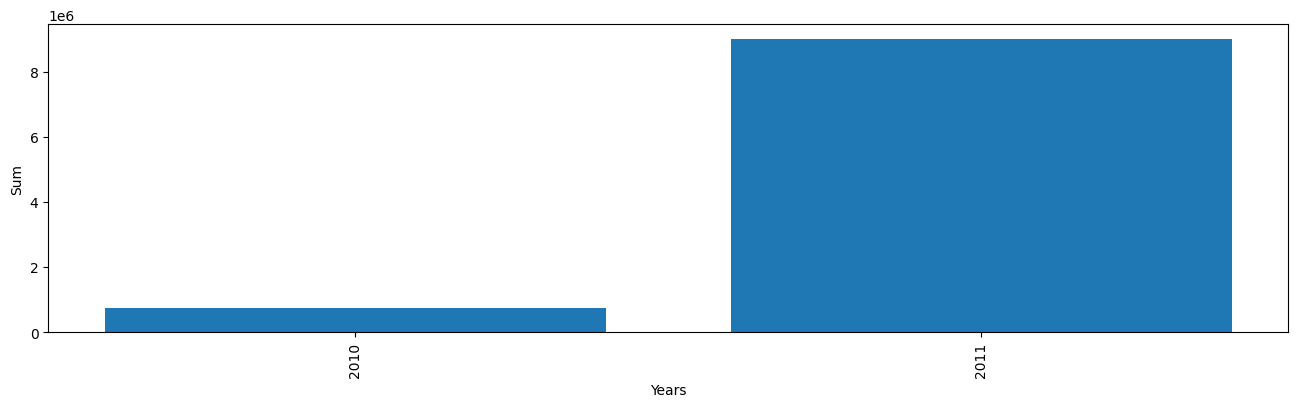

In [8]:
dates = rows[:, header.index("InvoiceDate")]
monthly_data = {}
yearly_data = {}
for date in dates:
    monthly_data[date.split(" ")[0].split("/")[0]] = 0
    yearly_data[date.split(" ")[0].split("/")[-1]] = 0

date_index = header.index("InvoiceDate")
quantity_index = header.index("Quantity")
unit_price_index = header.index("UnitPrice")
for row in rows:
    date = row[date_index]
    monthly_data[date.split(" ")[0].split("/")[0]] += float(
        row[quantity_index]
    ) * float(row[unit_price_index])
    yearly_data[date.split(" ")[0].split("/")[-1]] += float(
        row[quantity_index]
    ) * float(row[unit_price_index])


x = monthly_data.keys()
y = monthly_data.values()
plt.figure(figsize=(16, 4))
plt.bar(x, y)
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Sum")
plt.show()

x = yearly_data.keys()
y = yearly_data.values()
plt.figure(figsize=(16, 4))
plt.bar(x, y)
plt.xticks(rotation=90)
plt.xlabel("Years")
plt.ylabel("Sum")
plt.show()

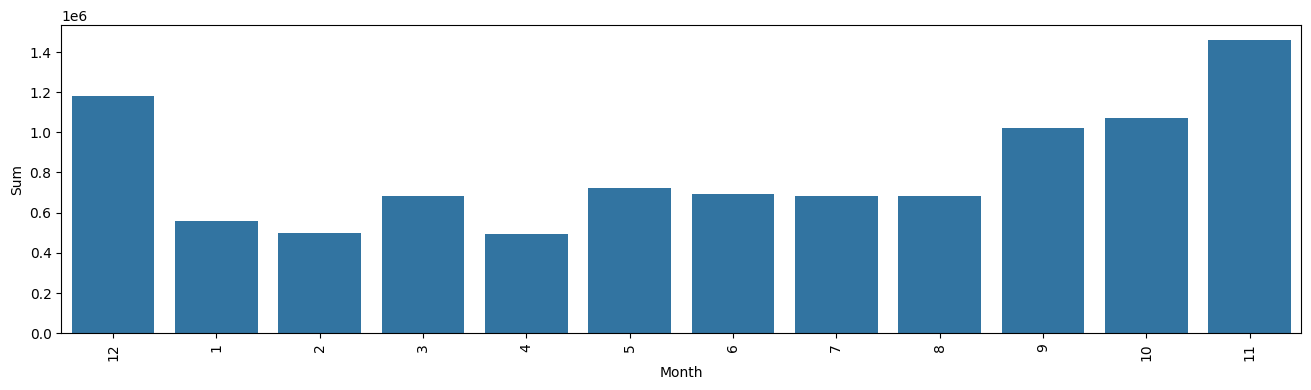

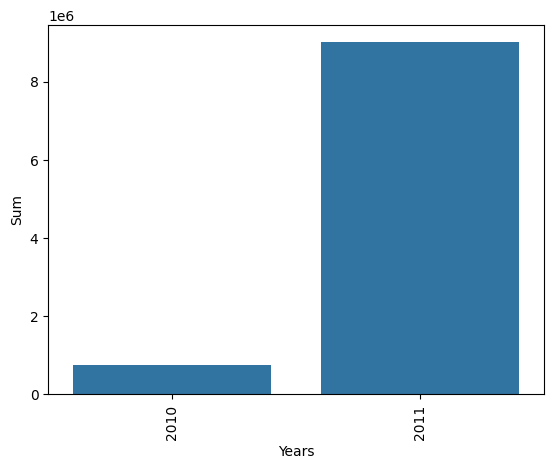

In [9]:
x = monthly_data.keys()
y = monthly_data.values()
plt.figure(figsize=(16, 4))
sns.barplot(x=x, y=y)
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Sum")
plt.show()

x = yearly_data.keys()
y = yearly_data.values()
sns.barplot(x=x, y=y)
plt.xticks(rotation=90)
plt.xlabel("Years")
plt.ylabel("Sum")
plt.show()

In [10]:
quantites_col = rows[:, header.index("Quantity")].astype(np.float32)
unit_price_col = rows[:, header.index("UnitPrice")].astype(np.float32)

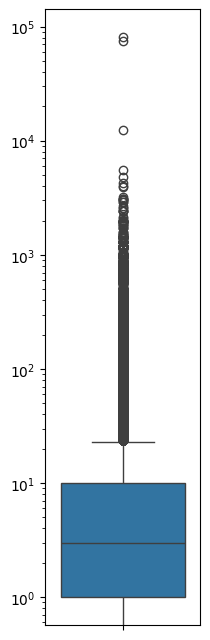

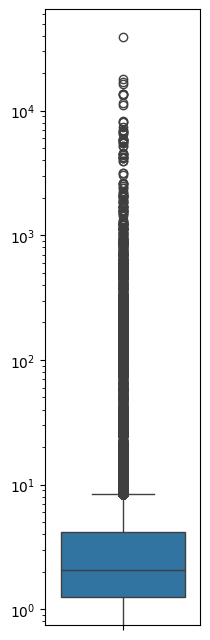

In [11]:
plt.figure(figsize=(2, 8))
sns.boxplot(quantites_col)
plt.yscale("log")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(2, 8))
sns.boxplot(unit_price_col)
plt.yscale("log")
plt.xticks(rotation=90)
plt.show()

<Figure size 1600x400 with 0 Axes>

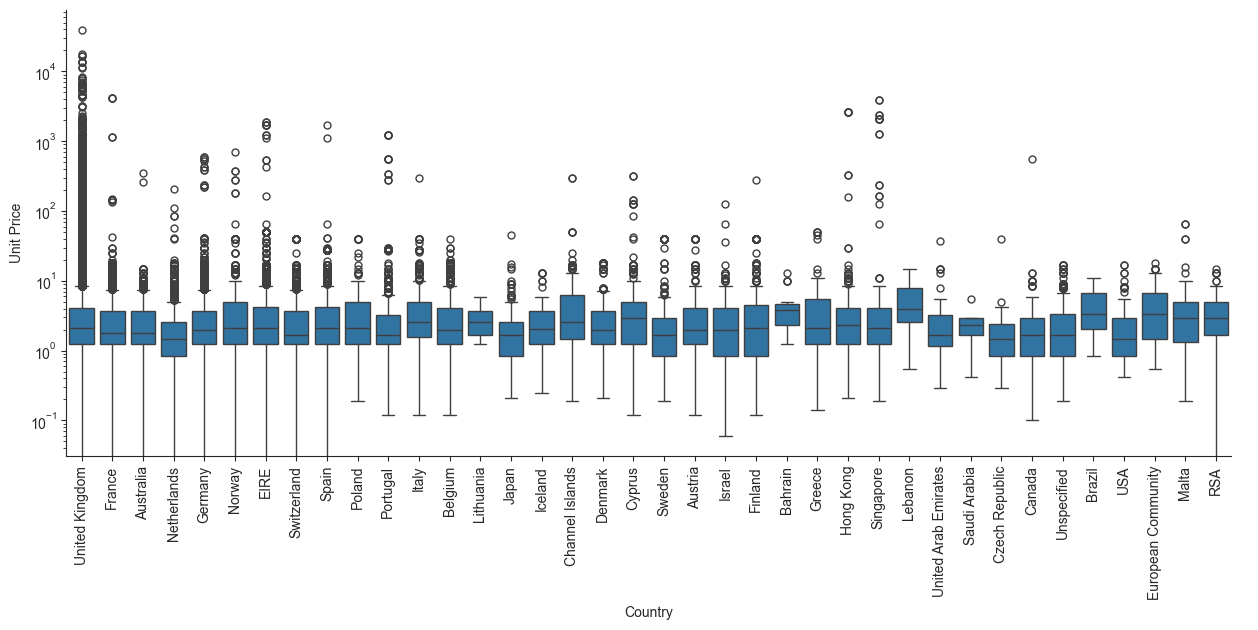

<Figure size 1600x400 with 0 Axes>

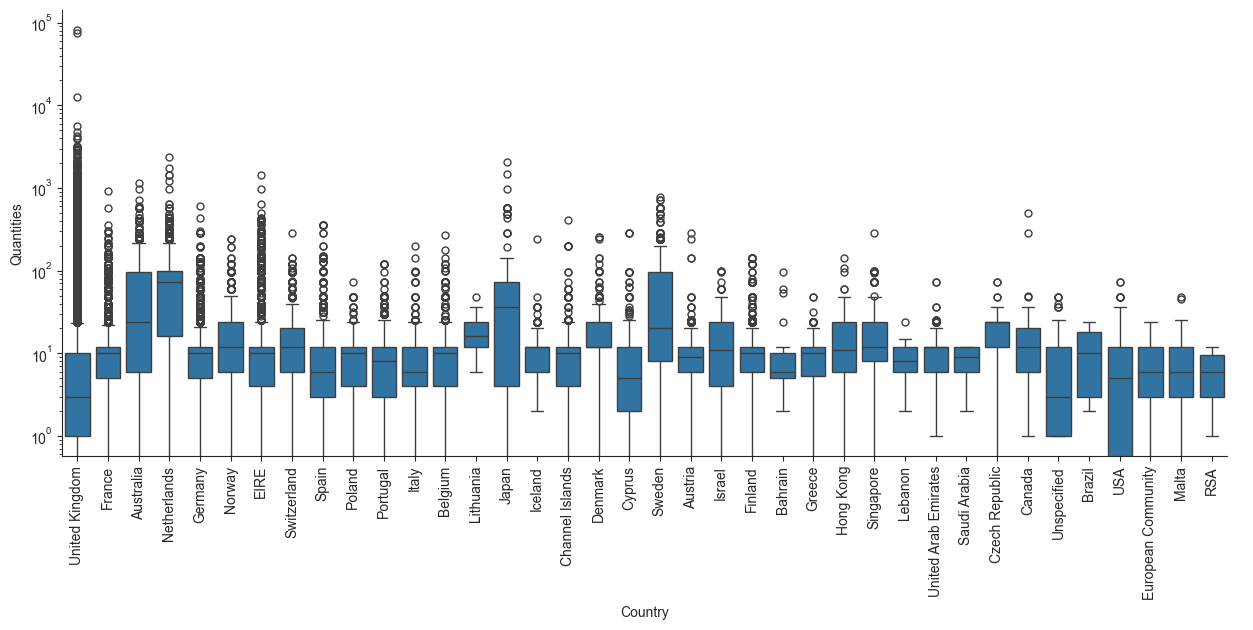

In [12]:
with sns.axes_style(style="ticks"):
    plt.figure(figsize=(16, 4))
    g = sns.catplot(x=countries, y=unit_price_col, kind="box", height=5, aspect=2.5)
    plt.xticks(rotation=90)
    g.set_axis_labels("Country", "Unit Price")
    plt.yscale("log")
    plt.show()

with sns.axes_style(style="ticks"):
    plt.figure(figsize=(16, 4))
    g = sns.catplot(x=countries, y=quantites_col, kind="box", height=5, aspect=2.5)
    plt.xticks(rotation=90)
    g.set_axis_labels("Country", "Quantities")
    plt.yscale("log")
    plt.show()